# Proyecto - MLP para Predicción de Series Temporales

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## 1. Carga de datos

In [ ]:
import gc
gc.collect()

train_df = pd.read_parquet('datasets/train.parquet')
test_df = pd.read_parquet('datasets/test.parquet')

# Drop weight column early to save memory (not used as feature)
train_weights = train_df['weight'].values  # keep if needed for evaluation
train_df.drop(columns=['weight'], inplace=True)

print(f"Full Train shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")

# Subsample: keep complete entities (code + sub_code combos) to preserve full time evolution
# Get unique entity keys
entity_keys = train_df[['code', 'sub_code']].drop_duplicates()
print(f"Total unique (code, sub_code) entities: {len(entity_keys)}")

# Sample ~40% of entities (ensures manageable memory while keeping full temporal data)
np.random.seed(42)
sample_frac = 0.1
sampled_entities = entity_keys.sample(frac=sample_frac, random_state=42)
print(f"Sampled entities: {len(sampled_entities)} ({sample_frac*100:.0f}%)")

# Filter train_df to only include sampled entities
train_df = train_df.merge(sampled_entities, on=['code', 'sub_code'], how='inner').reset_index(drop=True)

# Verify all sub_categories and horizons are represented
print(f"\nSubsampled Train shape: {train_df.shape}")
print(f"Sub-categories in sample: {train_df['sub_category'].nunique()} / {test_df['sub_category'].nunique()}")
print(f"Horizons in sample: {sorted(train_df['horizon'].unique())}")
print(f"ts_index range: {train_df['ts_index'].min()} - {train_df['ts_index'].max()}")
print(f"\nTarget stats:\n{train_df['y_target'].describe()}")
print(f"\nMemory usage: {train_df.memory_usage(deep=True).sum() / 1e9:.2f} GB")

gc.collect()

Full Train shape: (5337414, 93)
Test shape: (1447107, 92)
Total unique (code, sub_code) entities: 1856
Sampled entities: 186 (10%)

Subsampled Train shape: (523244, 93)
Sub-categories in sample: 5 / 5
Horizons in sample: [np.int32(1), np.int32(3), np.int32(10), np.int32(25)]
ts_index range: 1 - 3601

Target stats:
count    523244.000000
mean         -0.326457
std          34.974414
min       -1067.027099
25%          -0.127514
50%          -0.000515
75%           0.054727
max        1521.665638
Name: y_target, dtype: float64

Memory usage: 0.50 GB


0

## 2. Preprocesamiento

- Codificación de variables categóricas (code, sub_code, sub_category, horizon) con LabelEncoder para embeddings
- Imputación de valores nulos con 0
- Normalización de features numéricas con StandardScaler
- No se usa `weight` como feature (solo para evaluación)

In [3]:
# Define feature columns
feature_cols = [c for c in train_df.columns if c.startswith('feature_')]
cat_cols = ['code', 'sub_code', 'sub_category', 'horizon']

print(f"Number of features: {len(feature_cols)}")
print(f"Categorical columns: {cat_cols}")

# Encode categorical variables (fit on train+test to handle all categories)
label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    combined = pd.concat([train_df[col], test_df[col]], axis=0)
    le.fit(combined)
    train_df[col + '_enc'] = le.transform(train_df[col]).astype(np.int32)
    test_df[col + '_enc'] = le.transform(test_df[col]).astype(np.int32)
    label_encoders[col] = le
    print(f"  {col}: {len(le.classes_)} unique values")

cat_enc_cols = [c + '_enc' for c in cat_cols]

# Drop original categorical string columns to save memory
train_df.drop(columns=cat_cols + ['id'], inplace=True)
test_ids = test_df['id'].values  # save for submission
test_df.drop(columns=cat_cols + ['id'], inplace=True)
gc.collect()
print(f"\nMemory after dropping strings: {train_df.memory_usage(deep=True).sum() / 1e9:.2f} GB")

Number of features: 86
Categorical columns: ['code', 'sub_code', 'sub_category', 'horizon']
  code: 23 unique values
  sub_code: 149 unique values
  sub_category: 5 unique values
  horizon: 4 unique values

Memory after dropping strings: 0.37 GB


In [4]:
# Convert features to float32 and fill NaN in-place to save memory
for col in feature_cols:
    train_df[col] = train_df[col].fillna(0).astype(np.float32)
for col in feature_cols:
    test_df[col] = test_df[col].fillna(0).astype(np.float32)

gc.collect()

# Normalize numerical features (fit on train only, transform both)
# Use partial_fit approach to avoid creating full copy
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# Fit scaler on train data
scaler.fit(train_df[feature_cols])

# Transform in chunks to reduce peak memory
chunk_size = 20  # process 20 columns at a time
for i in range(0, len(feature_cols), chunk_size):
    cols_chunk = feature_cols[i:i+chunk_size]
    idx = list(range(i, min(i+chunk_size, len(feature_cols))))
    train_df[cols_chunk] = ((train_df[cols_chunk].values - scaler.mean_[idx]) / scaler.scale_[idx]).astype(np.float32)
    test_df[cols_chunk] = ((test_df[cols_chunk].values - scaler.mean_[idx]) / scaler.scale_[idx]).astype(np.float32)

gc.collect()
print("Preprocessing complete.")
print(f"Train NaN count: {train_df[feature_cols].isnull().sum().sum()}")
print(f"Memory usage train: {train_df.memory_usage(deep=True).sum() / 1e9:.2f} GB")
print(f"Memory usage test: {test_df.memory_usage(deep=True).sum() / 1e9:.2f} GB")

Preprocessing complete.
Train NaN count: 0
Memory usage train: 0.19 GB
Memory usage test: 0.53 GB


In [5]:
# Split training data into train/validation using time-based split
# Use last portion of ts_index as validation (respects temporal order)
val_cutoff = int(train_df['ts_index'].max() * 0.85)  # ~85% for training
print(f"Validation cutoff ts_index: {val_cutoff}")

train_mask = train_df['ts_index'] <= val_cutoff
val_mask = train_df['ts_index'] > val_cutoff

train_split = train_df[train_mask].reset_index(drop=True)
val_split = train_df[val_mask].reset_index(drop=True)

print(f"Train split: {len(train_split)} rows (ts_index 1-{val_cutoff})")
print(f"Val split: {len(val_split)} rows (ts_index {val_cutoff+1}-{train_df['ts_index'].max()})")

Validation cutoff ts_index: 3060
Train split: 412374 rows (ts_index 1-3060)
Val split: 110870 rows (ts_index 3061-3601)


## 3. Dataset y DataLoader

In [6]:
class TimeSeriesDataset(Dataset):
    def __init__(self, df, feature_cols, cat_enc_cols, target_col=None):
        self.features = torch.tensor(df[feature_cols].values, dtype=torch.float32)
        self.categoricals = torch.tensor(df[cat_enc_cols].values, dtype=torch.long)
        self.ts_index = torch.tensor(df['ts_index'].values, dtype=torch.float32).unsqueeze(1)
        if target_col and target_col in df.columns:
            self.targets = torch.tensor(df[target_col].values, dtype=torch.float32)
        else:
            self.targets = None

    def __len__(self):
        return len(self.features)

    def __getitem__(self, idx):
        x_num = self.features[idx]
        x_cat = self.categoricals[idx]
        x_ts = self.ts_index[idx]
        if self.targets is not None:
            return x_num, x_cat, x_ts, self.targets[idx]
        return x_num, x_cat, x_ts

In [7]:
BATCH_SIZE = 4096

train_dataset = TimeSeriesDataset(train_split, feature_cols, cat_enc_cols, 'y_target')
val_dataset = TimeSeriesDataset(val_split, feature_cols, cat_enc_cols, 'y_target')
test_dataset = TimeSeriesDataset(test_df, feature_cols, cat_enc_cols)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

Train batches: 101
Val batches: 28
Test batches: 354


## 4. Arquitectura MLP con Embeddings

In [8]:
class TimeSeriesMLP(nn.Module):
    def __init__(self, num_features, cat_cardinalities, embed_dims, hidden_dims, dropout=0.3):
        """
        Args:
            num_features: number of numerical features (86)
            cat_cardinalities: list of number of unique values per categorical
            embed_dims: list of embedding dimensions per categorical
            hidden_dims: list of hidden layer sizes
            dropout: dropout rate
        """
        super().__init__()

        # Embedding layers for categoricals
        self.embeddings = nn.ModuleList([
            nn.Embedding(card, dim) for card, dim in zip(cat_cardinalities, embed_dims)
        ])

        # Total input dim = numerical features + sum of embedding dims + 1 (ts_index normalized)
        total_embed_dim = sum(embed_dims)
        input_dim = num_features + total_embed_dim + 1

        # Build MLP layers
        layers = []
        prev_dim = input_dim
        for h_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, h_dim))
            layers.append(nn.BatchNorm1d(h_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            prev_dim = h_dim

        # Output layer
        layers.append(nn.Linear(prev_dim, 1))

        self.mlp = nn.Sequential(*layers)

    def forward(self, x_num, x_cat, x_ts):
        # Get embeddings for each categorical
        embeds = [emb(x_cat[:, i]) for i, emb in enumerate(self.embeddings)]
        embeds = torch.cat(embeds, dim=1)

        # Normalize ts_index to [0, 1] range approximately
        x_ts_norm = x_ts / 4376.0

        # Concatenate all inputs
        x = torch.cat([x_num, embeds, x_ts_norm], dim=1)

        return self.mlp(x).squeeze(1)

In [17]:
# Model hyperparameters
NUM_FEATURES = len(feature_cols)  # 86
cat_cardinalities = [
    len(label_encoders['code'].classes_),       # 23
    len(label_encoders['sub_code'].classes_),    # 180
    len(label_encoders['sub_category'].classes_),# 5
    len(label_encoders['horizon'].classes_),     # 4
]
embed_dims = [8, 16, 4, 4]  # Embedding dimensions for each categorical
hidden_dims = [2048, 1024, 512, 256, 128, 64]
DROPOUT = 0.3
LEARNING_RATE = 1e-3
NUM_EPOCHS = 30

model = TimeSeriesMLP(
    num_features=NUM_FEATURES,
    cat_cardinalities=cat_cardinalities,
    embed_dims=embed_dims,
    hidden_dims=hidden_dims,
    dropout=DROPOUT
).to(device)

print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal parameters: {total_params:,}")

TimeSeriesMLP(
  (embeddings): ModuleList(
    (0): Embedding(23, 8)
    (1): Embedding(149, 16)
    (2): Embedding(5, 4)
    (3): Embedding(4, 4)
  )
  (mlp): Sequential(
    (0): Linear(in_features=119, out_features=2048, bias=True)
    (1): BatchNorm1d(2048, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=2048, out_features=1024, bias=True)
    (5): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=1024, out_features=512, bias=True)
    (9): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=512, out_features=256, bias=True)
    (13): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): ReLU()
    (15): Dropout(p=0.3, inp

## 5. Entrenamiento

In [18]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0
    n_samples = 0
    for x_num, x_cat, x_ts, y in loader:
        x_num, x_cat, x_ts, y = x_num.to(device), x_cat.to(device), x_ts.to(device), y.to(device)

        optimizer.zero_grad()
        pred = model(x_num, x_cat, x_ts)
        loss = criterion(pred, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item() * len(y)
        n_samples += len(y)

    return total_loss / n_samples

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0
    n_samples = 0
    for x_num, x_cat, x_ts, y in loader:
        x_num, x_cat, x_ts, y = x_num.to(device), x_cat.to(device), x_ts.to(device), y.to(device)
        pred = model(x_num, x_cat, x_ts)
        loss = criterion(pred, y)
        total_loss += loss.item() * len(y)
        n_samples += len(y)
    return total_loss / n_samples

In [12]:
best_val_loss = float('inf')
history = {'train_loss': [], 'val_loss': []}

for epoch in range(NUM_EPOCHS):
    train_loss = train_epoch(model, train_loader, criterion, optimizer)
    val_loss = evaluate(model, val_loader, criterion)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)

    scheduler.step(val_loss)

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f} | LR: {optimizer.param_groups[0]['lr']:.2e}")

    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_model.pt')
        print(f"  -> Best model saved (val_loss: {val_loss:.6f})")

print(f"\nBest validation loss: {best_val_loss:.6f}")

Epoch 1/15 | Train Loss: 1239.228239 | Val Loss: 1132.203771 | LR: 1.00e-03
  -> Best model saved (val_loss: 1132.203771)
Epoch 2/15 | Train Loss: 1137.808099 | Val Loss: 1249.868678 | LR: 1.00e-03
Epoch 3/15 | Train Loss: 1033.440077 | Val Loss: 1512.116500 | LR: 1.00e-03
Epoch 4/15 | Train Loss: 937.153562 | Val Loss: 1679.838993 | LR: 5.00e-04
Epoch 5/15 | Train Loss: 855.635096 | Val Loss: 1779.536042 | LR: 5.00e-04
Epoch 6/15 | Train Loss: 809.039650 | Val Loss: 1806.831463 | LR: 5.00e-04
Epoch 7/15 | Train Loss: 775.111009 | Val Loss: 1949.654538 | LR: 2.50e-04
Epoch 8/15 | Train Loss: 728.286199 | Val Loss: 1990.124364 | LR: 2.50e-04
Epoch 9/15 | Train Loss: 699.893245 | Val Loss: 2034.712270 | LR: 2.50e-04
Epoch 10/15 | Train Loss: 682.464475 | Val Loss: 2161.229498 | LR: 1.25e-04
Epoch 11/15 | Train Loss: 663.361435 | Val Loss: 2119.703214 | LR: 1.25e-04
Epoch 12/15 | Train Loss: 651.943221 | Val Loss: 2163.559601 | LR: 1.25e-04
Epoch 13/15 | Train Loss: 653.757461 | Val Loss:

## 6. Reentrenamiento con todos los datos de training

Ahora que validamos la arquitectura, reentrenamos con todo el dataset de training para maximizar la generalización.

In [19]:
# Retrain on full training data
full_train_dataset = TimeSeriesDataset(train_df, feature_cols, cat_enc_cols, 'y_target')
full_train_loader = DataLoader(full_train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)

# Reinitialize model
model_final = TimeSeriesMLP(
    num_features=NUM_FEATURES,
    cat_cardinalities=cat_cardinalities,
    embed_dims=embed_dims,
    hidden_dims=hidden_dims,
    dropout=DROPOUT
).to(device)

optimizer_final = torch.optim.Adam(model_final.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)
scheduler_final = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_final, T_max=NUM_EPOCHS)

for epoch in range(NUM_EPOCHS):
    train_loss = train_epoch(model_final, full_train_loader, criterion, optimizer_final)
    scheduler_final.step()
    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | Train Loss: {train_loss:.6f} | LR: {optimizer_final.param_groups[0]['lr']:.2e}")

torch.save(model_final.state_dict(), 'final_model.pt')
print("\nFinal model saved.")

Epoch 1/30 | Train Loss: 1166.357206 | LR: 9.97e-04
Epoch 2/30 | Train Loss: 981.951049 | LR: 9.89e-04
Epoch 3/30 | Train Loss: 836.802632 | LR: 9.76e-04
Epoch 4/30 | Train Loss: 751.248744 | LR: 9.57e-04
Epoch 5/30 | Train Loss: 690.084274 | LR: 9.33e-04
Epoch 6/30 | Train Loss: 632.837278 | LR: 9.05e-04
Epoch 7/30 | Train Loss: 600.562168 | LR: 8.72e-04
Epoch 8/30 | Train Loss: 574.428527 | LR: 8.35e-04
Epoch 9/30 | Train Loss: 544.684545 | LR: 7.94e-04
Epoch 10/30 | Train Loss: 526.375048 | LR: 7.50e-04
Epoch 11/30 | Train Loss: 510.531878 | LR: 7.03e-04
Epoch 12/30 | Train Loss: 474.940491 | LR: 6.55e-04
Epoch 13/30 | Train Loss: 462.250224 | LR: 6.04e-04
Epoch 14/30 | Train Loss: 444.056430 | LR: 5.52e-04
Epoch 15/30 | Train Loss: 430.694876 | LR: 5.00e-04
Epoch 16/30 | Train Loss: 418.028193 | LR: 4.48e-04
Epoch 17/30 | Train Loss: 396.018038 | LR: 3.96e-04
Epoch 18/30 | Train Loss: 395.085805 | LR: 3.45e-04
Epoch 19/30 | Train Loss: 381.194120 | LR: 2.97e-04
Epoch 20/30 | Train 

## 7. Predicción sobre test y generación de submission

In [20]:
@torch.no_grad()
def predict(model, loader):
    model.eval()
    predictions = []
    for batch in loader:
        x_num, x_cat, x_ts = batch[0].to(device), batch[1].to(device), batch[2].to(device)
        pred = model(x_num, x_cat, x_ts)
        predictions.append(pred.cpu().numpy())
    return np.concatenate(predictions)

# Generate predictions
test_predictions = predict(model_final, test_loader)

# Create submission dataframe
submission = pd.DataFrame({
    'id': test_ids,
    'y_target': test_predictions
})

print(f"Submission shape: {submission.shape}")
print(f"Prediction stats:\n{submission['y_target'].describe()}")

# Save submission
submission.to_csv('submission.csv', index=False)
print("\nSubmission saved to submission.csv")

Submission shape: (1447107, 2)
Prediction stats:
count    1.447107e+06
mean    -1.972221e+00
std      2.949748e+01
min     -1.342174e+03
25%     -1.935351e-01
50%     -5.697373e-02
75%      8.096989e-02
max      7.658684e+02
Name: y_target, dtype: float64

Submission saved to submission.csv


## 8. Visualización de resultados

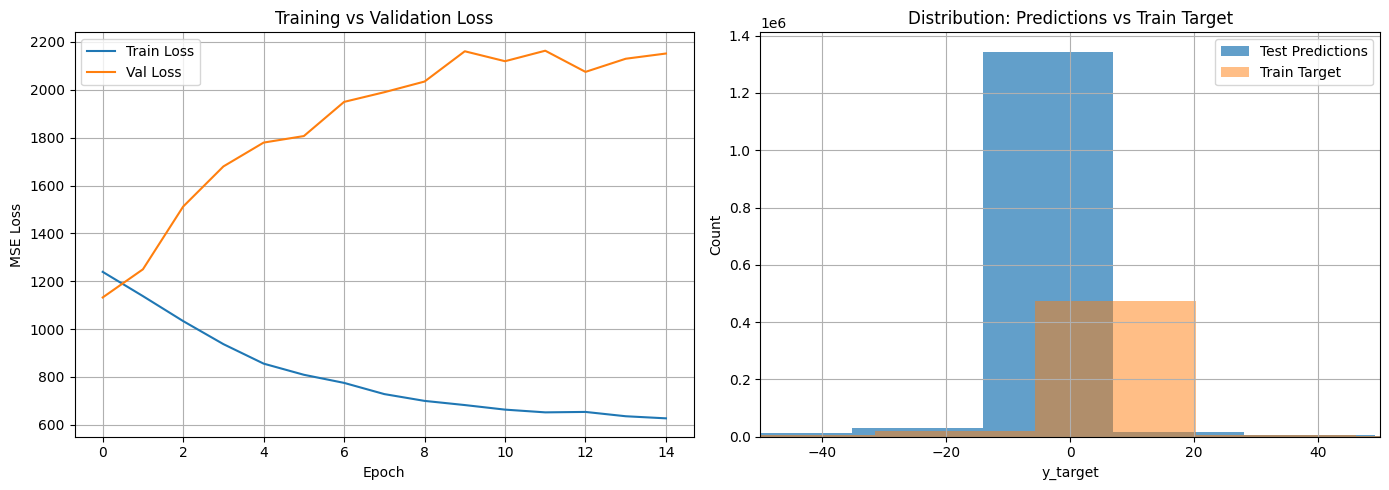

In [21]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training curves
axes[0].plot(history['train_loss'], label='Train Loss')
axes[0].plot(history['val_loss'], label='Val Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].set_title('Training vs Validation Loss')
axes[0].legend()
axes[0].grid(True)

# Prediction distribution
axes[1].hist(test_predictions, bins=100, alpha=0.7, label='Test Predictions')
axes[1].hist(train_df['y_target'].values, bins=100, alpha=0.5, label='Train Target')
axes[1].set_xlabel('y_target')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution: Predictions vs Train Target')
axes[1].legend()
axes[1].set_xlim(-50, 50)
axes[1].grid(True)

plt.tight_layout()
plt.show()

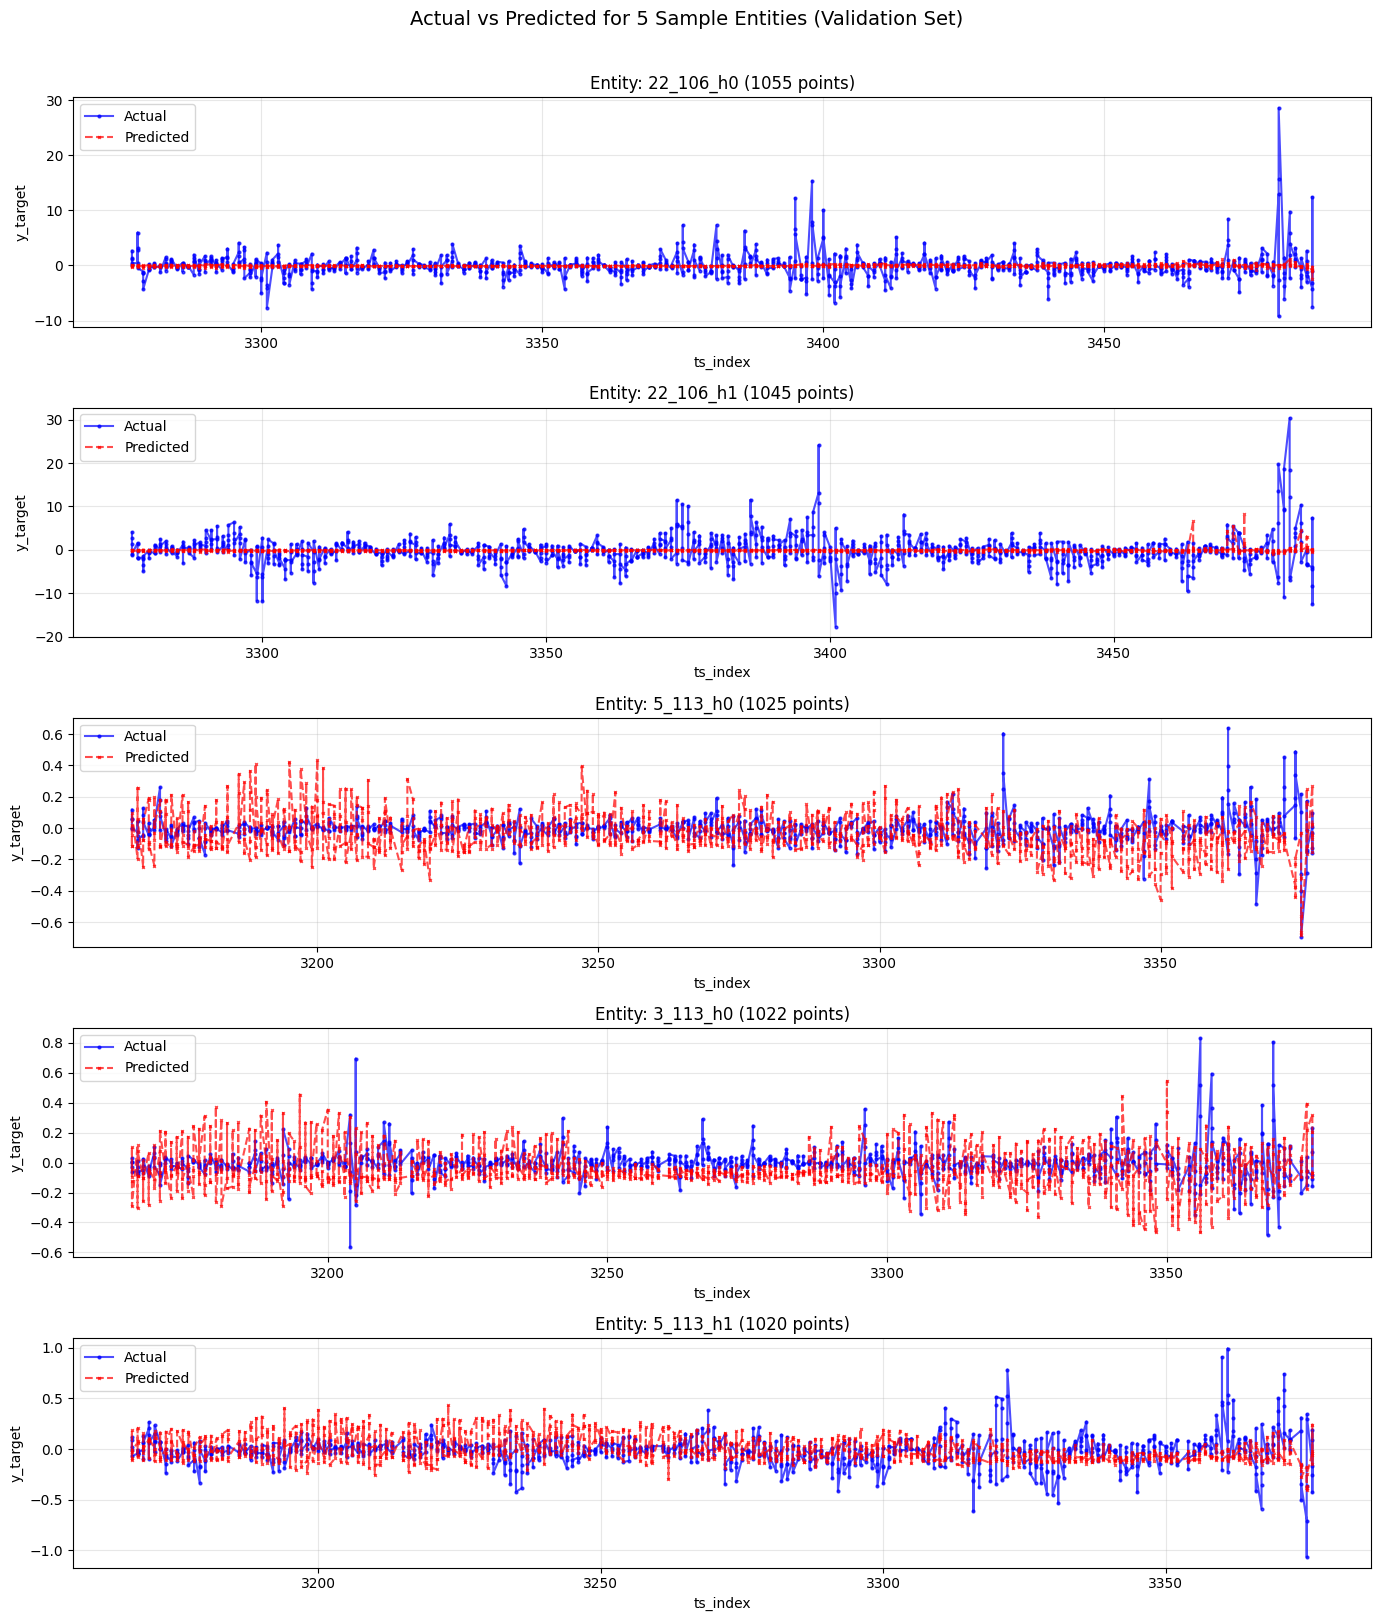

In [23]:
# Plot time vs actual/predicted for 5 sample entities on validation set
# Get predictions on validation set
val_predictions = predict(model_final, val_loader)

# Build a df with ts_index, actual, predicted, and entity identifiers
val_plot_df = pd.DataFrame({
    'ts_index': val_split['ts_index'].values,
    'y_actual': val_split['y_target'].values,
    'y_pred': val_predictions,
    'code_enc': val_split['code_enc'].values,
    'sub_code_enc': val_split['sub_code_enc'].values,
    'horizon_enc': val_split['horizon_enc'].values,
})

# Create entity key from encoded categoricals
val_plot_df['entity'] = val_plot_df['code_enc'].astype(str) + '_' + val_plot_df['sub_code_enc'].astype(str) + '_h' + val_plot_df['horizon_enc'].astype(str)

# Pick 5 entities with enough data points
entity_counts = val_plot_df['entity'].value_counts()
selected_entities = entity_counts[entity_counts >= 20].head(5).index.tolist()

fig, axes = plt.subplots(5, 1, figsize=(14, 16), sharex=False)

for i, entity in enumerate(selected_entities):
    subset = val_plot_df[val_plot_df['entity'] == entity].sort_values('ts_index')
    axes[i].plot(subset['ts_index'], subset['y_actual'], 'b-o', markersize=2, label='Actual', alpha=0.7)
    axes[i].plot(subset['ts_index'], subset['y_pred'], 'r--x', markersize=2, label='Predicted', alpha=0.7)
    axes[i].set_title(f'Entity: {entity} ({len(subset)} points)')
    axes[i].set_xlabel('ts_index')
    axes[i].set_ylabel('y_target')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Actual vs Predicted for 5 Sample Entities (Validation Set)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()